##Task: to undertsand how charges (insurance premium)is affected by factors: age, bmi, children covered by the insurance, smoking habit and region of residance and apply appropriate regression model
https://www.kaggle.com/datasets/thedevastator/prediction-of-insurance-charges-using-age-gender



In [ ]:
from google.colab import files

In [ ]:
files.upload()

Saving insurance.csv to insurance (1).csv


{'insurance (1).csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,sou

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


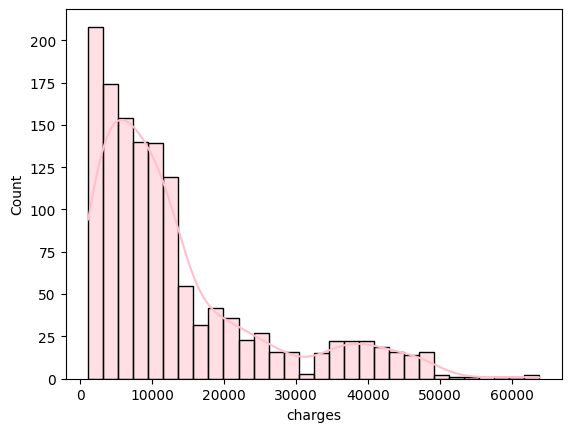

In [ ]:
#for general dirtibution of charges
sns.histplot(df['charges'], kde=True, color='pink');


In [ ]:
df['charges'].mode()

,charges
0,1639.5631


obervation: right skewed (possible question: what could be causing some ppl such high charge)

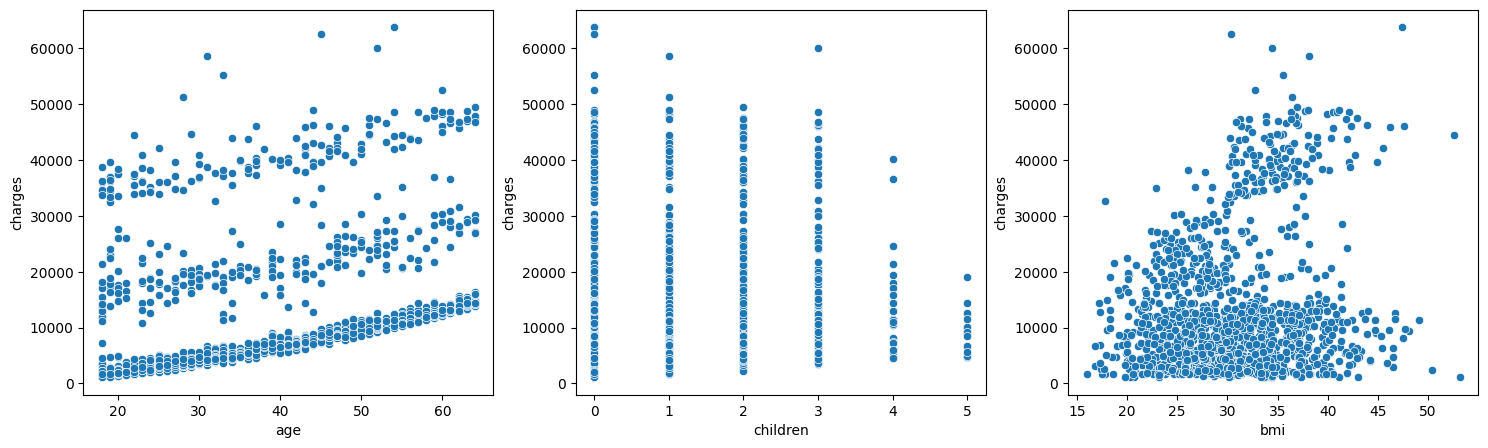

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=df['age'], y=df['charges'], ax=axes[0])
sns.scatterplot(x=df['children'], y=df['charges'], ax=axes[1])
sns.scatterplot(x=df['bmi'], y=df['charges'], ax=axes[2]);

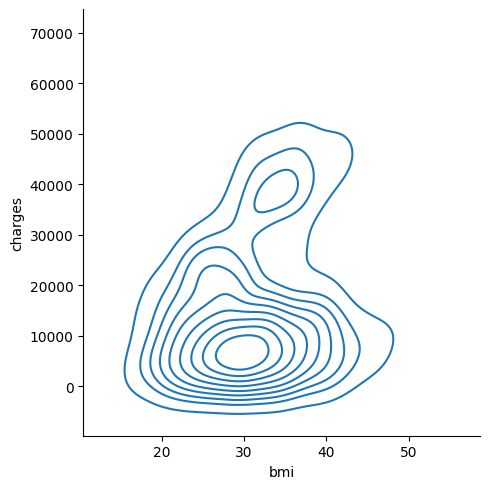

In [ ]:
#scatterplot of bmi has overplotting
sns.displot(x='bmi', y='charges', data=df, kind='kde')


charges seem to be increasing with age. Charges start higher with greater number of children. BMI seems to have two categories: one a lower cluster, and other with increasing trend

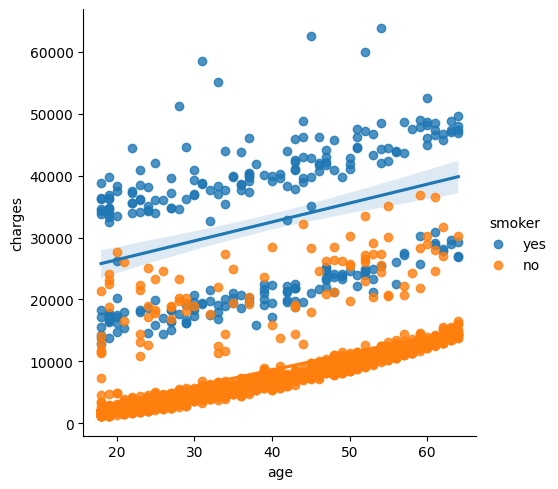

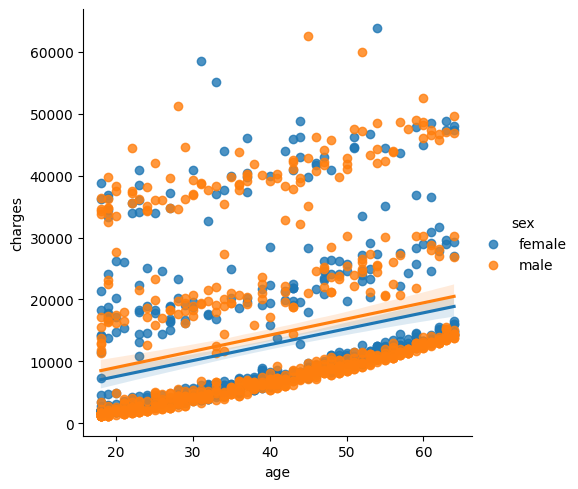

In [ ]:
# what could be causing the general trend in ages/charges graph to divide into 3 categories?
sns.lmplot(data = df, x='age', y='charges', hue='smoker')
sns.lmplot(data = df, x='age', y='charges', hue='sex')

For non-smokers, there is a strong trend as illustrated by dense cluster around regression line with some general spread. One category in age/charge looks like its for non-smokers. For smokers, there seems to be 2 categories again. Sex doesn't seem to affect charges compared to smoking.

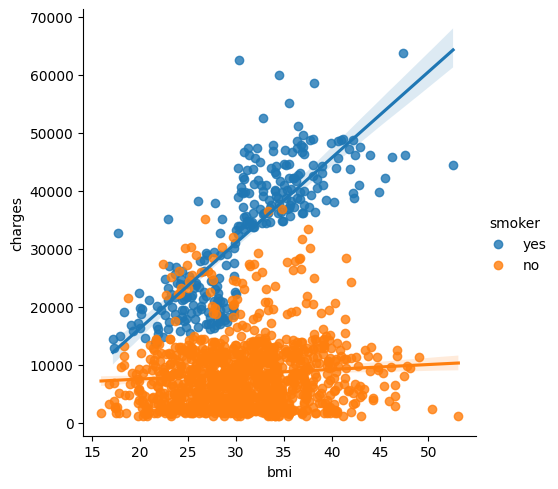

In [ ]:
#for bmi
sns.lmplot(x='bmi', y='charges', hue='smoker', data=df)

In [ ]:
df_normalbmi= df[df['bmi']<25]

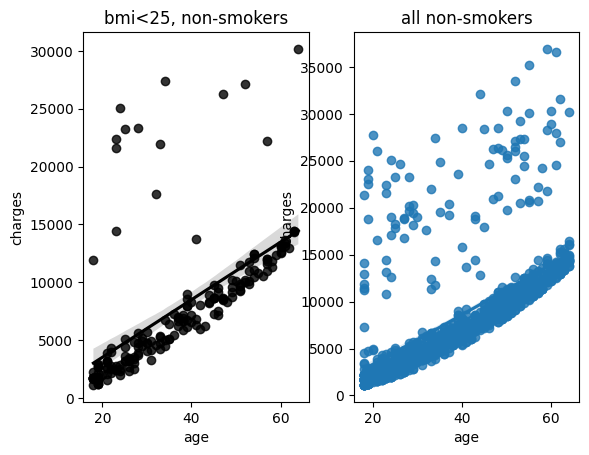

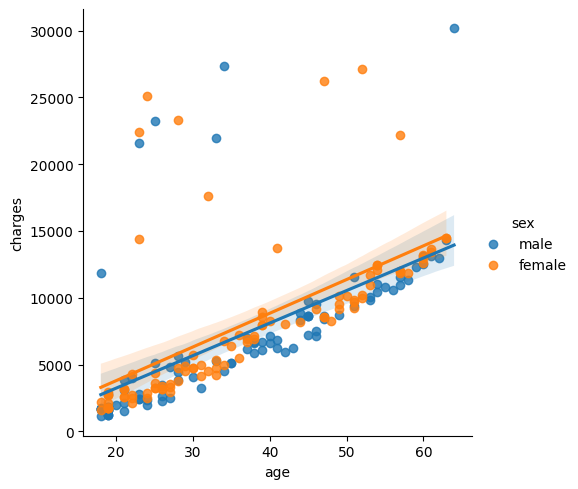

In [ ]:
fig, axeooo = plt.subplots(1,2)
sns.regplot(data=df_normalbmi[df_normalbmi['smoker']=='no'], x = 'age', y='charges', ax=axeooo[0], color='black')
axeooo[0].set_title('bmi<25, non-smokers')
sns.regplot(data=df[df['smoker']=='no'], x='age', y='charges', ax=axeooo[1])
axeooo[1].set_title('all non-smokers')
sns.lmplot(data=df_normalbmi[df_normalbmi['smoker']=='no'], x = 'age', y='charges', hue='sex')

Text(0.5, 1.0, 'all smokers')

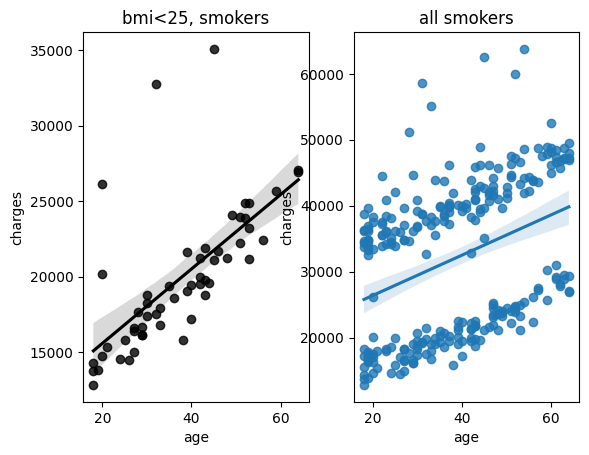

In [ ]:
fig, axeoo = plt.subplots(1,2)
sns.regplot(data=df_normalbmi[df_normalbmi['smoker']=='yes'], x = 'age', y='charges', ax=axeoo[0], color='black')
axeoo[0].set_title('bmi<25, smokers')
sns.regplot(data=df[df['smoker']=='yes'], x='age', y='charges', ax=axeoo[1])
axeoo[1].set_title('all smokers')

So, bmi does account for some anomality in charges.I am considering BMI because normal is 18-24.9 but maximum of our data is 53 and median is above 25. However, in doing so, I am reducing the sample size drastically. Hence, it is not practical.

In [ ]:
df_anormalbmi= df[df['bmi']>=25]

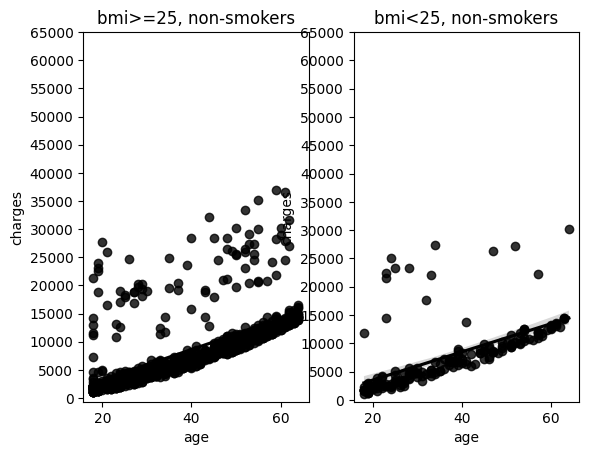

In [ ]:
from numpy._core.defchararray import title
fig, axeo = plt.subplots(1,2)
sns.regplot(data=df_anormalbmi[df_anormalbmi['smoker']=='no'], x = 'age', y='charges', ax=axeo[0], color='black')
axeo[0].set_title('bmi>=25, non-smokers')
sns.regplot(data=df_normalbmi[df_normalbmi['smoker']=='no'], x = 'age', y='charges', ax=axeo[1], color='black')
axeo[1].set_title('bmi<25, non-smokers')
axeo[0].set_yticks(range(0, int(df_anormalbmi['charges'].max())+5000, 5000));
axeo[1].set_yticks(range(0, int(df_anormalbmi['charges'].max())+5000, 5000));

here, we see that for bmi>=25 non-smokers, the variation of age with charges is similar to the variation for all. So, BMI doesn't explain the segregation.

/tmp/ipython-input-507769617.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=pd.cut(df['bmi'], bins=[0,25,30,35,40,54]), y='charges', data=df, palette='pastel')


<Axes: xlabel='bmi', ylabel='charges'>

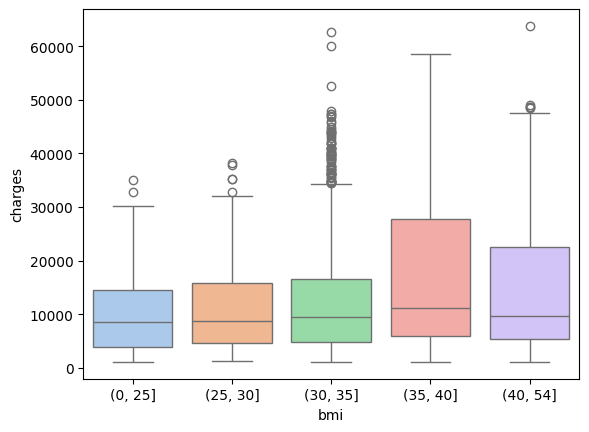

In [ ]:
# we see that bmi also affects charges. Considering only bmi and charges:
sns.boxplot(x=pd.cut(df['bmi'], bins=[0,25,30,35,40,54]), y='charges', data=df, palette='pastel')

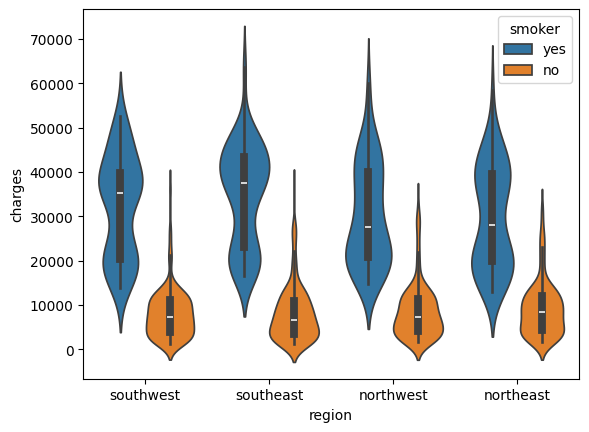

In [ ]:
#region
sns.violinplot(x='region', y='charges', hue='smoker', data=df);
#sns.catplot(x='region', y='charges', data=df, kind='box')

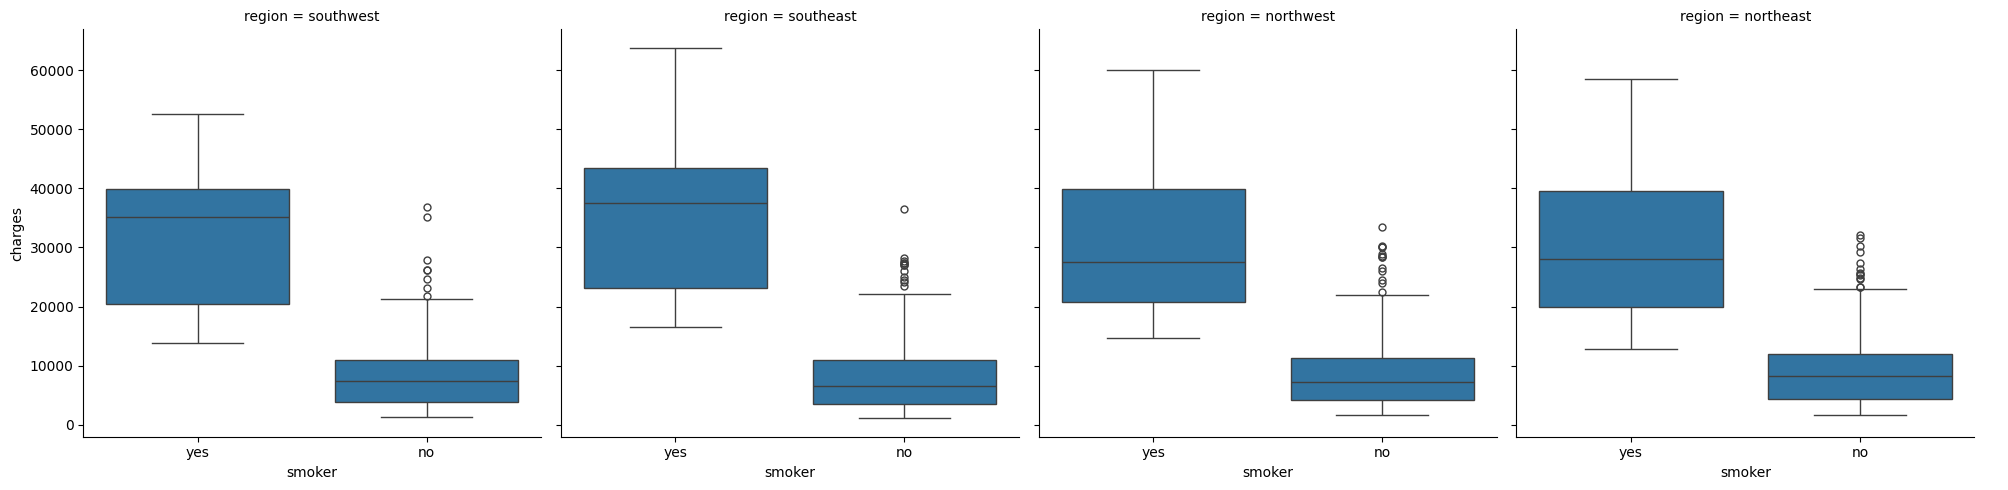

In [ ]:
sns.catplot(x='smoker', y='charges', col='region', kind='box', data=df)


charges in southwest and southeast for smokers are higher(esp. median). More outliers for non-smokers than smokers. For non-smokers, charges seem to be generally higher for northeast.

*side note= I had used violin-plot without hue ='smoker' initially. hence all the work below and boxplots because distribution wasn't as clear*

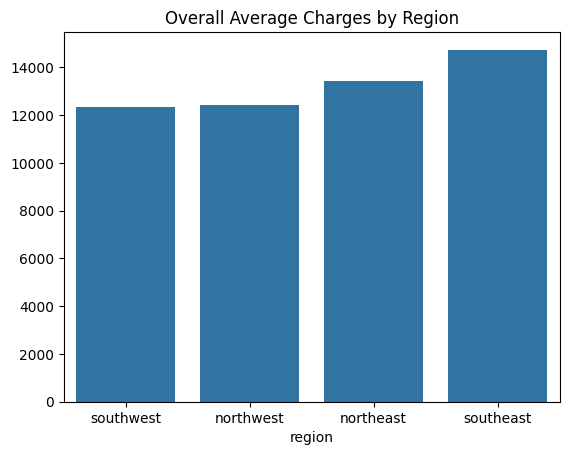

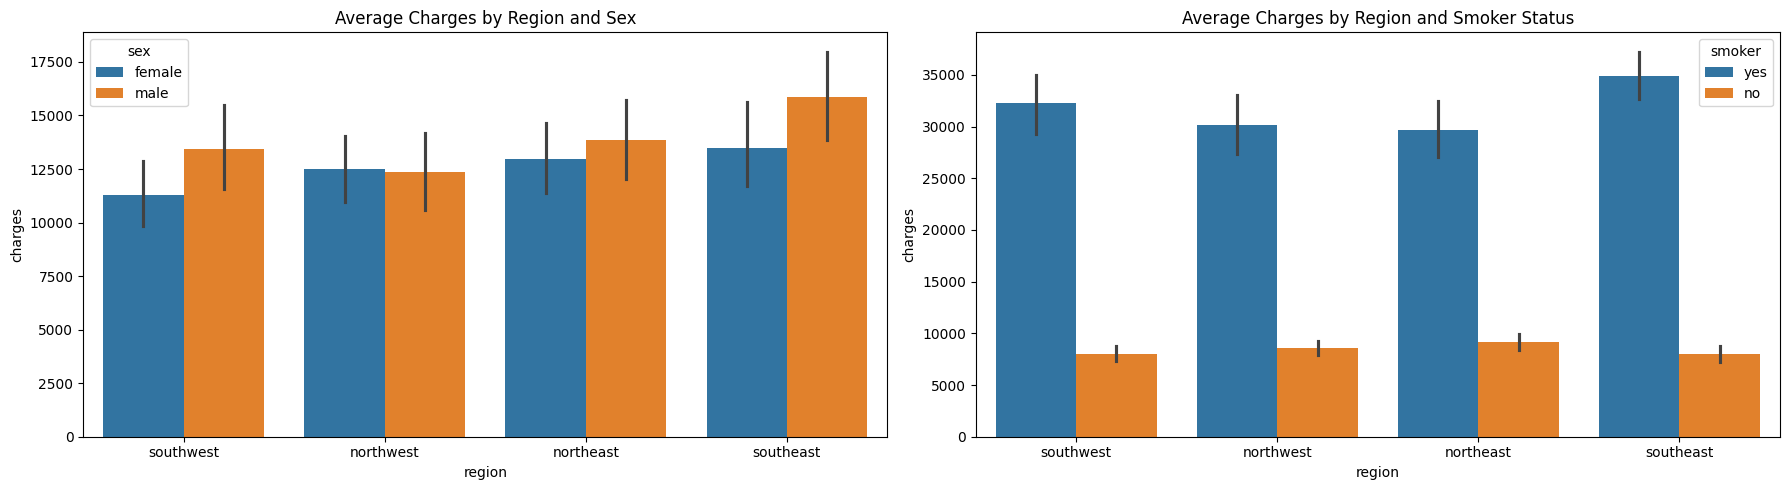

In [ ]:
#to see overall average by region
#average of charges in each region barplot
charges = df['charges'].groupby(df.region).mean().sort_values()
#the estimator parameter in Seaborn controls how the data within each category is summarized before being plotted. it is easier to use but not used here
#because we are also sorting values to make it easier to read.
sns.barplot(y=charges.values, x=charges.index).set_title('Overall Average Charges by Region')
fig, ab = plt.subplots(1,2, figsize=(18,5))
sns.barplot(x=df['region'], y=df['charges'], hue=df['smoker'], ax=ab[1], estimator='mean', order=charges.index)
ab[1].set_title('Average Charges by Region and Smoker Status')
sns.barplot(x=df['region'], y=df['charges'], hue=df['sex'], ax=ab[0], estimator='mean', order=charges.index)
ab[0].set_title('Average Charges by Region and Sex')
plt.tight_layout()

Charges are greater for male than female (especially in southeast),except in northwest. Although southwest has lowest average charges, average charge for smoker is second highest. Conversely, northeast has lowest average for smokers.

<Axes: xlabel='children', ylabel='charges'>

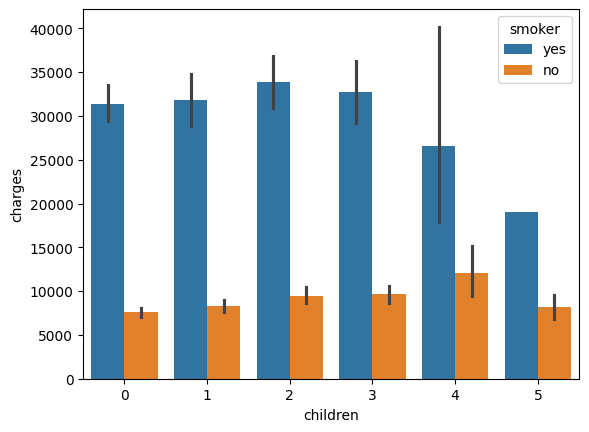

In [ ]:
#what about children?
sns.barplot(x='children', y='charges', data=df, hue='smoker', estimator=np.mean)


not a consistent pattern

Till now, I have concluded smoking habit is the most significant factor. Charges increases with age. It is also affected by region.

<Axes: >

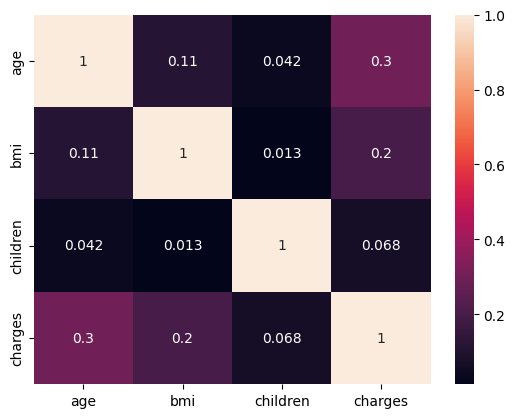

In [ ]:
sns.heatmap(data=df[['age','bmi', 'children','charges']].corr(), annot=True)

heatmap doesn't suggest any strong correlation.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = LabelEncoder().fit_transform(df[col])


<Axes: >

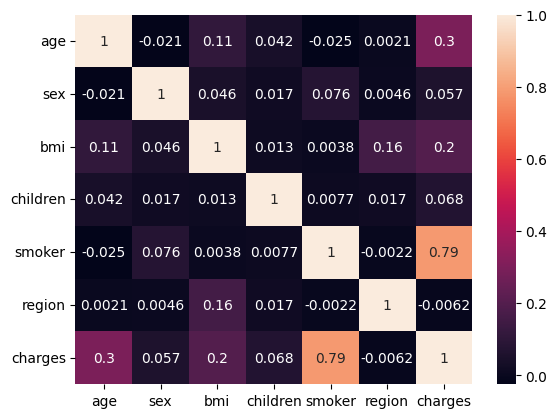

In [ ]:
sns.heatmap(df_encoded.corr(), annot=True)

In [ ]:
X = df_encoded.drop('charges', axis=1)
#axis=0 for dropping column
y=df_encoded['charges']

In [ ]:
from sklearn.model_selection import train_test_split as holdout
from sklearn.linear_model import LinearRegression
from sklearn import metrics
x_train, x_test, y_train, y_test = holdout(X, y, test_size=0.2, random_state=0)
Lin_reg = LinearRegression()
Lin_reg.fit(x_train, y_train)
print(Lin_reg.intercept_)
print(Lin_reg.coef_)
print(Lin_reg.score(x_test, y_test))
print(Lin_reg.score(x_train, y_train))

-11661.98390882441
[  253.99185244   -24.32455098   328.40261701   443.72929547
 23568.87948381  -288.50857254]
0.7998747145449959
0.7368306228430944


So, 0.80 means our model is good enough but to improve, we try other models

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

#Scale data because ridge is affected by square cofficients and our data has outliers
X_scaled = StandardScaler().fit_transform(X)

# Automatically find best alpha
ridge_cv = RidgeCV(cv=5)
ridge_cv.fit(X_scaled, y)
print("Best alpha=",ridge_cv.alpha_)

Best alpha= 1.0


In [ ]:
from sklearn.linear_model import Ridge
X_train, X_test, y_train, y_test = holdout(X_scaled, y, test_size=0.2, random_state=0)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("train_score =", ridge.score(X_train, y_train))
print("test_score =", ridge.score(X_test, y_test))

train_score = 0.7368299529608392
test_score = 0.7998032670491303


not much change in lin_reg score and ridge reg score. Ideally, ridge regression could be used when independent variables are related (not here)

In [ ]:
# Use LassoCV to find best alpha automatically
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso
lasso_cv=LassoCV(cv=5)
lasso_cv.fit(X_scaled,y)
print(lasso_cv.alpha_)




50.85906581731453


In [ ]:
lasso = Lasso(alpha=lasso_cv.alpha_)
lasso.fit(X_train, y_train)
print(lasso.intercept_)
print(lasso.coef_)
print("r2",lasso.score(X_test, y_test))
y_test_pred=lasso.predict(x_test)


13226.933430643212
[3524.33582973   -0.         1948.29732564  485.89640497 9459.03645681
 -259.87620251]
r2 0.7988682734608088


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


In [ ]:
xyz = {
    'Feature': X.columns,
    'Lasso_Coefficient': lasso.coef_
}
df_coeffs = pd.DataFrame(xyz)
print(df_coeffs.sort_values(by='Lasso_Coefficient', key=lambda x: x.abs(), ascending=False))

    Feature  Lasso_Coefficient
4    smoker        9459.036457
0       age        3524.335830
2       bmi        1948.297326
3  children         485.896405
5    region        -259.876203
1       sex          -0.000000


Here, we can see which factors have most effect using lasso regression.


In [ ]:
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_test_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Mean Squared Error: 42573687462.08398
Root Mean Squared Error: 206333.92222822687


Maybe the error is too high. So, we try more regression models.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
# Use df_encoded where categorical features are already numerical
x = df_encoded.drop(['sex','region','charges'], axis = 1)
y = df_encoded.charges # Use y from df_encoded as well
pol = PolynomialFeatures (degree = 2)
x_pol = pol.fit_transform(x)
x_train, x_test, y_train, y_test = holdout(x_pol, y, test_size=0.2, random_state=0)
Pol_reg = LinearRegression()
Pol_reg.fit(x_train, y_train)
print(Pol_reg.score(x_test,y_test))

0.8812595703345227


In [ ]:
y_test_pred_pol = Pol_reg.predict(x_test)
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_test_pred_pol))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_pol)))

Mean Squared Error: 18895160.098780412
Root Mean Squared Error: 4346.856346692448
